In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/electriccsv/electricFeesApril.csv


In [2]:
# First, run this to verify file paths
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/electriccsv/electricFeesApril.csv


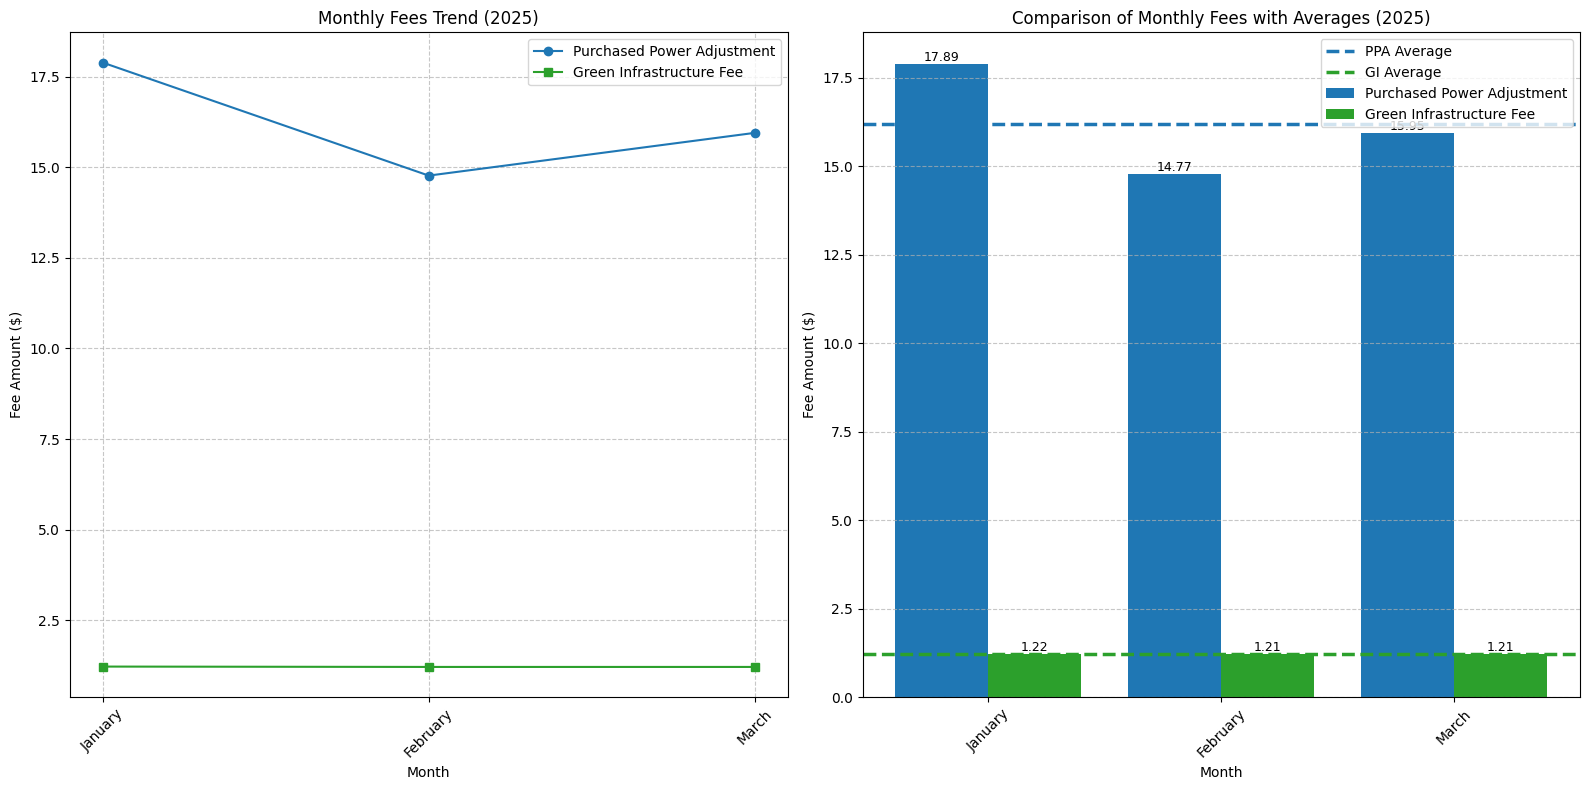

In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from calendar import month_name

# Load the dataset
df = pd.read_csv('/kaggle/input/electriccsv/electricFeesApril.csv')

# Data preparation
# Convert Month to categorical with proper ordering
df['Month'] = pd.Categorical(df['Month'], categories=list(month_name)[1:13], ordered=True)
df = df.sort_values('Month')

# Calculate averages
ppa_avg = df['Purchased_Power_Adjustement'].mean()
gi_avg = df['Green_Infrasturcure_Fee'].mean()

# Create a figure with two subplots
plt.figure(figsize=(16, 8))

# Line plot (left subplot)
plt.subplot(1, 2, 1)
plt.plot(df['Month'], df['Purchased_Power_Adjustement'], marker='o', label='Purchased Power Adjustment', color='#1f77b4')
plt.plot(df['Month'], df['Green_Infrasturcure_Fee'], marker='s', label='Green Infrastructure Fee', color='#2ca02c')
plt.title('Monthly Fees Trend (2025)')
plt.xlabel('Month')
plt.ylabel('Fee Amount ($)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Bar chart with averages (right subplot)
plt.subplot(1, 2, 2)
width = 0.4  # Width of the bars
x = range(len(df['Month']))  # X-axis positions

# Plot bars
bars1 = plt.bar(x, df['Purchased_Power_Adjustement'], width, label='Purchased Power Adjustment', color='#1f77b4')
bars2 = plt.bar([i + width for i in x], df['Green_Infrasturcure_Fee'], width, label='Green Infrastructure Fee', color='#2ca02c')

# Add average lines
plt.axhline(ppa_avg, color='#1f77b4', linestyle='--', linewidth=2.5, label='PPA Average')
plt.axhline(gi_avg, color='#2ca02c', linestyle='--', linewidth=2.5, label='GI Average')

# Add value labels on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=9)

# Chart formatting
plt.title('Comparison of Monthly Fees with Averages (2025)')
plt.xlabel('Month')
plt.ylabel('Fee Amount ($)')
plt.xticks([i + width/2 for i in x], df['Month'], rotation=45)
plt.legend(loc='upper right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout()
plt.show()